# VQ-VAE Interpretability Analysis (Product Quantization)

Understand what the 3-token bottleneck with independent codebooks learns:
1. **Slot-Codebook Usage Matrix** (3 x 256) — per-slot code usage
2. **Per-slot entropy** — how diverse is each slot's codebook usage?
3. **Slot overlap** — with product quantization, Jaccard should be 0 by construction
4. **Token-to-pitch mapping** — what does each code "look like" on the pitch? Do the 3 slots capture different aspects?
5. **Ball position** — is the ball node reconstructed correctly?

In [1]:
# -- Setup (run once) --
!rm -rf thesis/
!git clone https://github.com/fegerar/thesis
!cd thesis && git checkout vq-vae-product

Cloning into 'thesis'...
remote: Enumerating objects: 520, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 520 (delta 97), reused 102 (delta 47), pack-reused 359 (from 1)
Receiving objects: 100% (520/520), 189.62 KiB | 6.12 MiB/s, done.
Resolving deltas: 100% (293/293), done.
Branch 'vq-vae-product' set up to track remote branch 'vq-vae-product' from 'origin'.
Switched to a new branch 'vq-vae-product'


In [2]:
!pip install -r thesis/requirements.txt
!pip install gdown

  Cloning https://github.com/fegerar/shapegraphs.git to /tmp/pip-req-build-occi2w0y
  Running command git clone --filter=blob:none --quiet https://github.com/fegerar/shapegraphs.git /tmp/pip-req-build-occi2w0y
  Resolved https://github.com/fegerar/shapegraphs.git to commit 87680a35aebbe01c285f021df6969e26a58c9286
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# Upload DFL data to Colab/Drive, or adjust path below
# No pickle download needed — we parse DFL XML directly now
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
os.chdir('/content')

In [4]:
import sys, os
os.chdir("thesis")
sys.path.insert(0, "src")

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_batch

from vqvae import VQVAELightningModule, ProductQuantizer
from vqvae.dataset import load_all_matches, FrameDataset, PITCH_X, PITCH_Y

In [6]:
# ---- CONFIG: set these ----
CONFIG_PATH = "config/vqvae_product.yml"
CHECKPOINT_PATH = "/content/drive/MyDrive/thesis/checkpoints/vqvae-product/epoch-109.ckpt"  # adjust
DATA_DIR = "/content/drive/MyDrive/thesis/data"  # directory with DFL XML files
SPLIT = "val"  # which split to analyze
MAX_BATCHES = None  # set to e.g. 200 to speed up; None = full split

In [7]:
# Load config, data, and model
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg["data"]
subsample = data_cfg.get("subsample", 25)
all_data, node_dim = load_all_matches(DATA_DIR, subsample=subsample)
n = len(all_data)

generator = torch.Generator().manual_seed(data_cfg["seed"])
indices = torch.randperm(n, generator=generator).tolist()
n_train = int(n * data_cfg["train_ratio"])
n_val = int(n * data_cfg["val_ratio"])

splits = {
    "train": indices[:n_train],
    "val": indices[n_train:n_train + n_val],
    "test": indices[n_train + n_val:],
}
split_data = [all_data[i] for i in splits[SPLIT]]
print(f"Split '{SPLIT}': {len(split_data)} frames")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lit_model = VQVAELightningModule.load_from_checkpoint(CHECKPOINT_PATH, map_location=device)
lit_model.eval()
lit_model.to(device)
model = lit_model.model

T = model.encoder.num_summary_tokens
is_product = isinstance(model.quantizer, ProductQuantizer)

if is_product:
    K = model.quantizer.K
    print(f"Product Quantizer: {T} independent codebooks, K={K} each")
else:
    K = model.quantizer.K
    print(f"Shared Quantizer: K={K}, T={T}")

print(f"Tokens per frame T={T}")

Loading match DFL-MAT-J03WMX...
  Loaded 29194 frames from DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WMX.xml
Loading match DFL-MAT-J03WN1...
  Loaded 28313 frames from DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml
Loading match DFL-MAT-J03WOH...
  Loaded 27443 frames from DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOH.xml
Loading match DFL-MAT-J03WOY...
  Loaded 28508 frames from DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOY.xml
Loading match DFL-MAT-J03WPY...
  Loaded 29243 frames from DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WPY.xml
Loading match DFL-MAT-J03WQQ...
  Loaded 28470 frames from DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WQQ.xml
Loading match DFL-MAT-J03WR9...
  Loaded 29363 frames from DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WR9.xml
Total: 200534 frames across 7 matches (node_dim=4)
Split 'val': 20053 frames
Product Quantizer: 3 independent codebook

## Collect tokens and ground-truth features for all frames

In [8]:
loader = DataLoader(FrameDataset(split_data), batch_size=256, shuffle=False, num_workers=2)

all_tokens = []   # list of (B, T) tensors
all_gt = []       # list of (B, N_max, 4) dense ground-truth

with torch.no_grad():
    for i, batch in enumerate(loader):
        if MAX_BATCHES is not None and i >= MAX_BATCHES:
            break
        batch = batch.to(device)
        tokens = model.encode(batch.x, batch.edge_index, batch.batch)  # (B, T)
        all_tokens.append(tokens.cpu())

        x_dense, mask = to_dense_batch(batch.x, batch.batch)  # (B, N_max, 4)
        all_gt.append(x_dense.cpu())

all_tokens = torch.cat(all_tokens, dim=0)  # (N_frames, T)
all_gt = torch.cat(all_gt, dim=0)          # (N_frames, N_max, 4)
print(f"Collected tokens: {all_tokens.shape}, GT: {all_gt.shape}")

Collected tokens: torch.Size([20053, 3]), GT: torch.Size([20053, 23, 4])


## 1. Slot-Codebook Usage Matrix

Each row = one of the T token slots. Each column = one of the K codebook entries.
With product quantization, each slot has its **own** codebook — codes are not shared.

**What to look for:**
- Different usage patterns per row = each slot captures different aspects (good)
- Broad usage = high codebook utilization
- Concentrated spikes = a few dominant patterns per slot

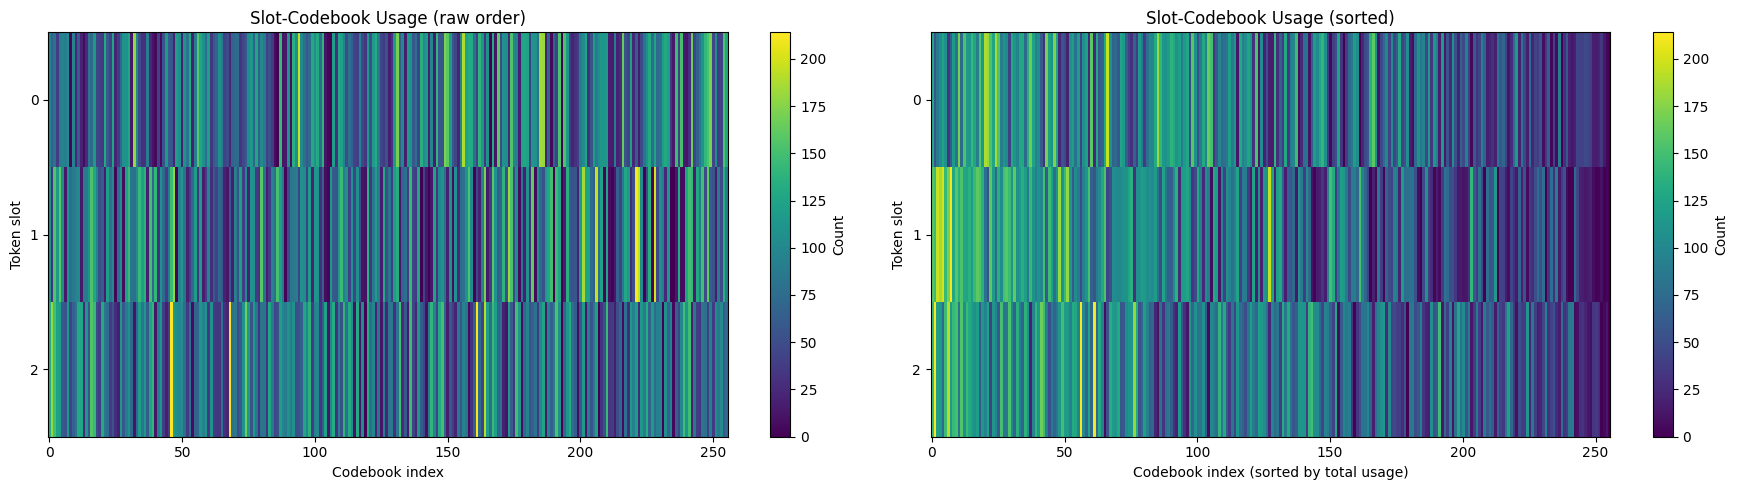

Slot 0: top-5 codes [np.int64(94), np.int64(156), np.int64(185), np.int64(32), np.int64(186)] cover 4.6% of frames
Slot 1: top-5 codes [np.int64(221), np.int64(228), np.int64(206), np.int64(222), np.int64(201)] cover 4.9% of frames
Slot 2: top-5 codes [np.int64(46), np.int64(161), np.int64(68), np.int64(164), np.int64(1)] cover 5.0% of frames


In [9]:
# Build slot-codebook usage matrix (T x K)
usage_matrix = np.zeros((T, K), dtype=np.int64)
for slot in range(T):
    codes = all_tokens[:, slot].numpy()
    for code in codes:
        usage_matrix[slot, code] += 1

# Sort columns by total usage for cleaner visualization
col_order = np.argsort(-usage_matrix.sum(axis=0))
usage_sorted = usage_matrix[:, col_order]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Raw matrix
im0 = axes[0].imshow(usage_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_xlabel("Codebook index")
axes[0].set_ylabel("Token slot")
axes[0].set_yticks(range(T))
axes[0].set_title("Slot-Codebook Usage (raw order)")
plt.colorbar(im0, ax=axes[0], label="Count")

# Sorted by total usage
im1 = axes[1].imshow(usage_sorted, aspect="auto", cmap="viridis", interpolation="nearest")
axes[1].set_xlabel("Codebook index (sorted by total usage)")
axes[1].set_ylabel("Token slot")
axes[1].set_yticks(range(T))
axes[1].set_title("Slot-Codebook Usage (sorted)")
plt.colorbar(im1, ax=axes[1], label="Count")

plt.tight_layout()
plt.show()

# Print top-5 codes per slot
for slot in range(T):
    top5 = np.argsort(-usage_matrix[slot])[:5]
    top5_counts = usage_matrix[slot, top5]
    total = usage_matrix[slot].sum()
    top5_pct = top5_counts.sum() / total * 100
    print(f"Slot {slot}: top-5 codes {list(top5)} cover {top5_pct:.1f}% of frames")

## 2. Per-Slot Entropy

Entropy measures how "spread out" each slot's codebook usage is.
- Max entropy = log2(K) = 8.0 bits (uniform over 256 codes)
- Low entropy = slot collapsed to a few codes (specialized or degenerate)

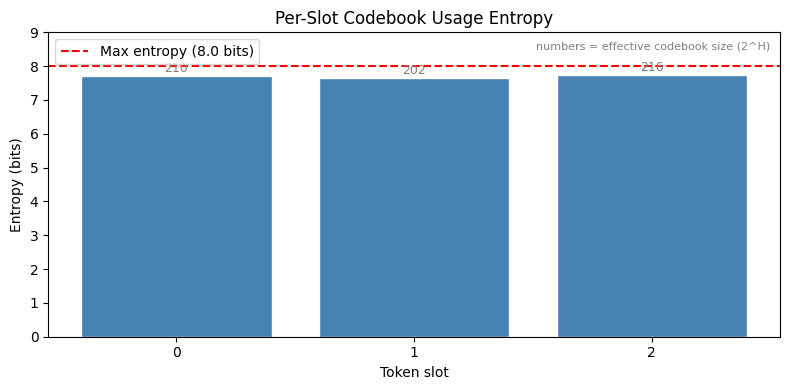

Slot 0: H=7.71 bits, effective=210 codes, actually used=254/256
Slot 1: H=7.66 bits, effective=202 codes, actually used=250/256
Slot 2: H=7.75 bits, effective=216 codes, actually used=253/256


In [10]:
from scipy.stats import entropy as sp_entropy

slot_entropies = []
for slot in range(T):
    counts = usage_matrix[slot].astype(np.float64)
    probs = counts / counts.sum()
    ent = sp_entropy(probs, base=2)
    slot_entropies.append(ent)

max_entropy = np.log2(K)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(T), slot_entropies, color="steelblue", edgecolor="white")
ax.axhline(max_entropy, color="red", linestyle="--", label=f"Max entropy ({max_entropy:.1f} bits)")
ax.set_xlabel("Token slot")
ax.set_ylabel("Entropy (bits)")
ax.set_title("Per-Slot Codebook Usage Entropy")
ax.set_xticks(range(T))
ax.legend()

for i, ent in enumerate(slot_entropies):
    n_effective = 2 ** ent
    ax.text(i, ent + 0.1, f"{n_effective:.0f}", ha="center", fontsize=9, color="gray")
ax.set_ylim(0, max_entropy + 1)
ax.text(T - 0.5, max_entropy + 0.5, "numbers = effective codebook size (2^H)", fontsize=8, ha="right", color="gray")

plt.tight_layout()
plt.show()

for slot, ent in enumerate(slot_entropies):
    n_used = (usage_matrix[slot] > 0).sum()
    print(f"Slot {slot}: H={ent:.2f} bits, effective={2**ent:.0f} codes, actually used={n_used}/{K}")

## 3. Slot Overlap (Jaccard similarity)

Do different slots use the same codes or different ones?
High Jaccard = slots share codes (less specialization). Low = distinct vocabularies per slot.

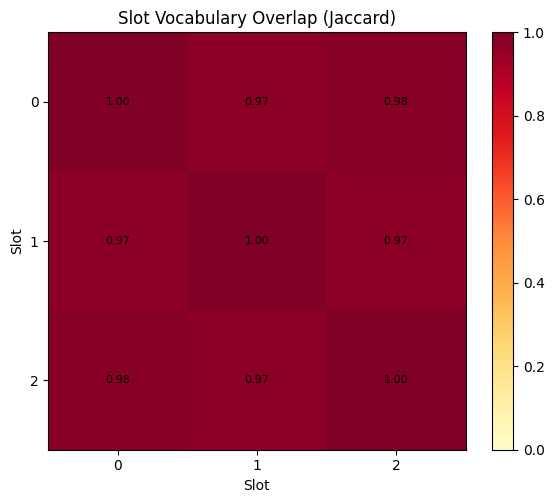

In [11]:
# Jaccard similarity between slot vocabularies
slot_sets = [set(np.where(usage_matrix[s] > 0)[0]) for s in range(T)]
jaccard = np.zeros((T, T))
for i in range(T):
    for j in range(T):
        inter = len(slot_sets[i] & slot_sets[j])
        union = len(slot_sets[i] | slot_sets[j])
        jaccard[i, j] = inter / union if union > 0 else 0

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jaccard, cmap="YlOrRd", vmin=0, vmax=1)
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{jaccard[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(T))
ax.set_yticks(range(T))
ax.set_xlabel("Slot")
ax.set_ylabel("Slot")
ax.set_title("Slot Vocabulary Overlap (Jaccard)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 4. Cross-Slot Co-occurrence

With product quantization, codes from different slots live in different codebooks.
This matrix shows which (slot_i, code_i) pairs tend to appear with which (slot_j, code_j) pairs.
We show pairwise co-occurrence between each slot pair's top codes.

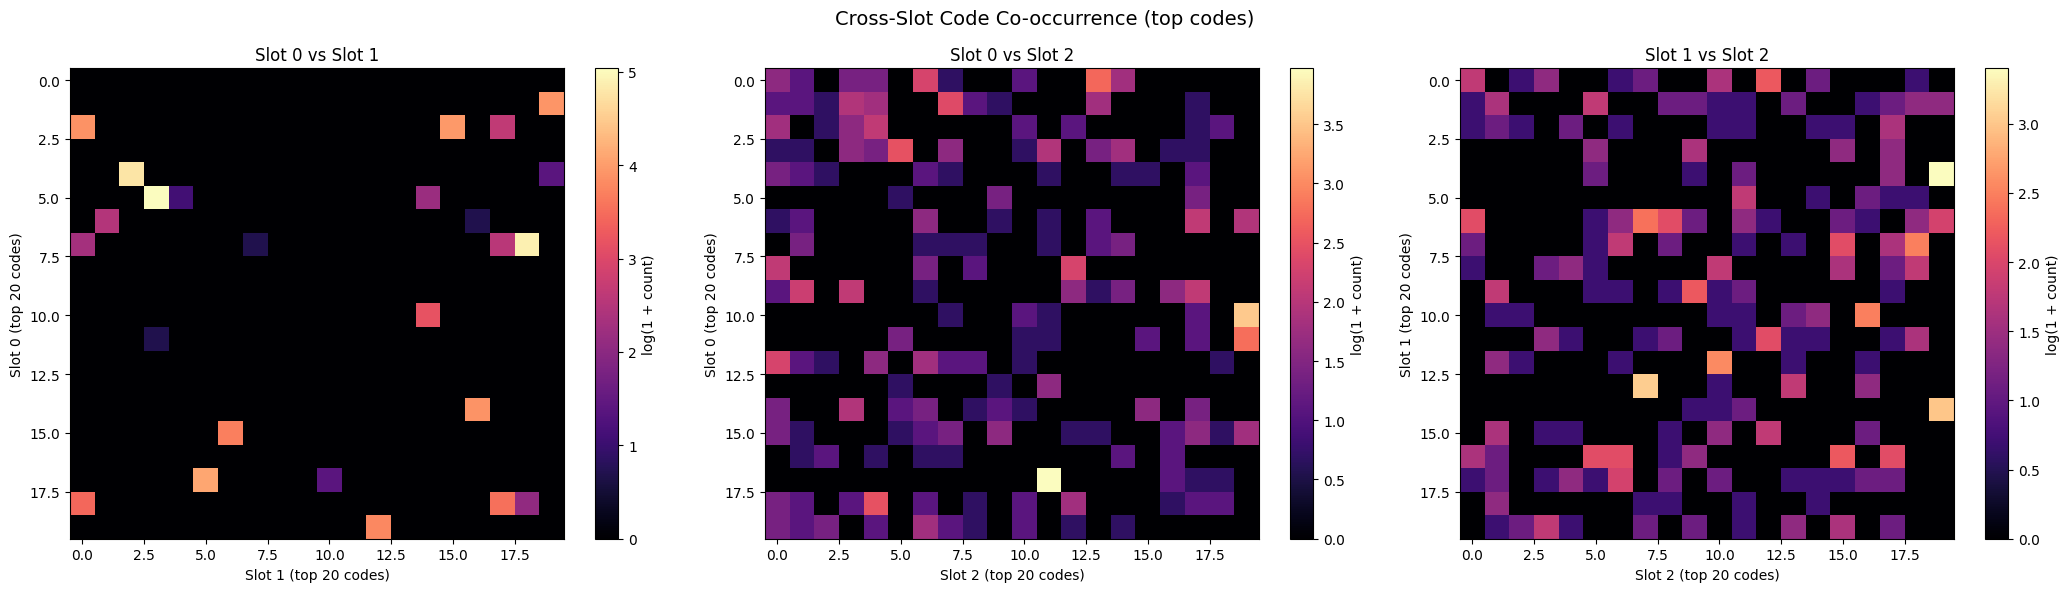

Slot 0: 254/256 codes used (99.2%)
Slot 1: 250/256 codes used (97.7%)
Slot 2: 253/256 codes used (98.8%)


In [12]:
# Cross-slot co-occurrence: for each pair of slots, show how their top codes co-occur
TOP_K = 20  # top codes per slot to include

fig, axes = plt.subplots(1, T * (T - 1) // 2, figsize=(7 * (T * (T - 1) // 2), 6))
if T * (T - 1) // 2 == 1:
    axes = [axes]

plot_idx = 0
for si in range(T):
    for sj in range(si + 1, T):
        ax = axes[plot_idx]
        codes_i = all_tokens[:, si].numpy()
        codes_j = all_tokens[:, sj].numpy()

        top_i = [c for c, _ in Counter(codes_i).most_common(TOP_K)]
        top_j = [c for c, _ in Counter(codes_j).most_common(TOP_K)]

        cooc = np.zeros((TOP_K, TOP_K), dtype=np.int64)
        for fi in range(len(codes_i)):
            ci, cj = codes_i[fi], codes_j[fi]
            if ci in top_i and cj in top_j:
                cooc[top_i.index(ci), top_j.index(cj)] += 1

        im = ax.imshow(np.log1p(cooc), aspect="auto", cmap="magma", interpolation="nearest")
        ax.set_xlabel(f"Slot {sj} (top {TOP_K} codes)")
        ax.set_ylabel(f"Slot {si} (top {TOP_K} codes)")
        ax.set_title(f"Slot {si} vs Slot {sj}")
        plt.colorbar(im, ax=ax, label="log(1 + count)")
        plot_idx += 1

plt.suptitle("Cross-Slot Code Co-occurrence (top codes)", fontsize=14)
plt.tight_layout()
plt.show()

# Per-slot utilization
for s in range(T):
    codes_s = all_tokens[:, s].numpy()
    n_used = len(set(codes_s))
    print(f"Slot {s}: {n_used}/{K} codes used ({n_used/K*100:.1f}%)")

## 5. Token-to-Pitch Mapping

For each codebook entry, average the ground-truth player positions of all frames that use it.
This reveals what each code "represents" spatially — e.g., a code might correspond to "compact defense on the left".

In [13]:
def draw_pitch(ax):
    """Draw a soccer pitch outline."""
    ax.set_xlim(-2, PITCH_X + 2)
    ax.set_ylim(-2, PITCH_Y + 2)
    ax.set_aspect("equal")
    ax.set_facecolor("#2e8b57")
    pitch = plt.Rectangle((0, 0), PITCH_X, PITCH_Y, fill=False, edgecolor="white", linewidth=1.5)
    ax.add_patch(pitch)
    ax.plot([PITCH_X/2, PITCH_X/2], [0, PITCH_Y], color="white", linewidth=1)
    center_circle = plt.Circle((PITCH_X/2, PITCH_Y/2), 9.15, fill=False, edgecolor="white", linewidth=1)
    ax.add_patch(center_circle)
    for x_start in [0, PITCH_X - 16.5]:
        pa = plt.Rectangle((x_start, (PITCH_Y - 40.3)/2), 16.5, 40.3, fill=False, edgecolor="white", linewidth=1)
        ax.add_patch(pa)
    ax.set_xticks([])
    ax.set_yticks([])

def denormalize(x_norm, y_norm):
    x = x_norm * (PITCH_X / 2) + (PITCH_X / 2)
    y = y_norm * (PITCH_Y / 2) + (PITCH_Y / 2)
    return x, y

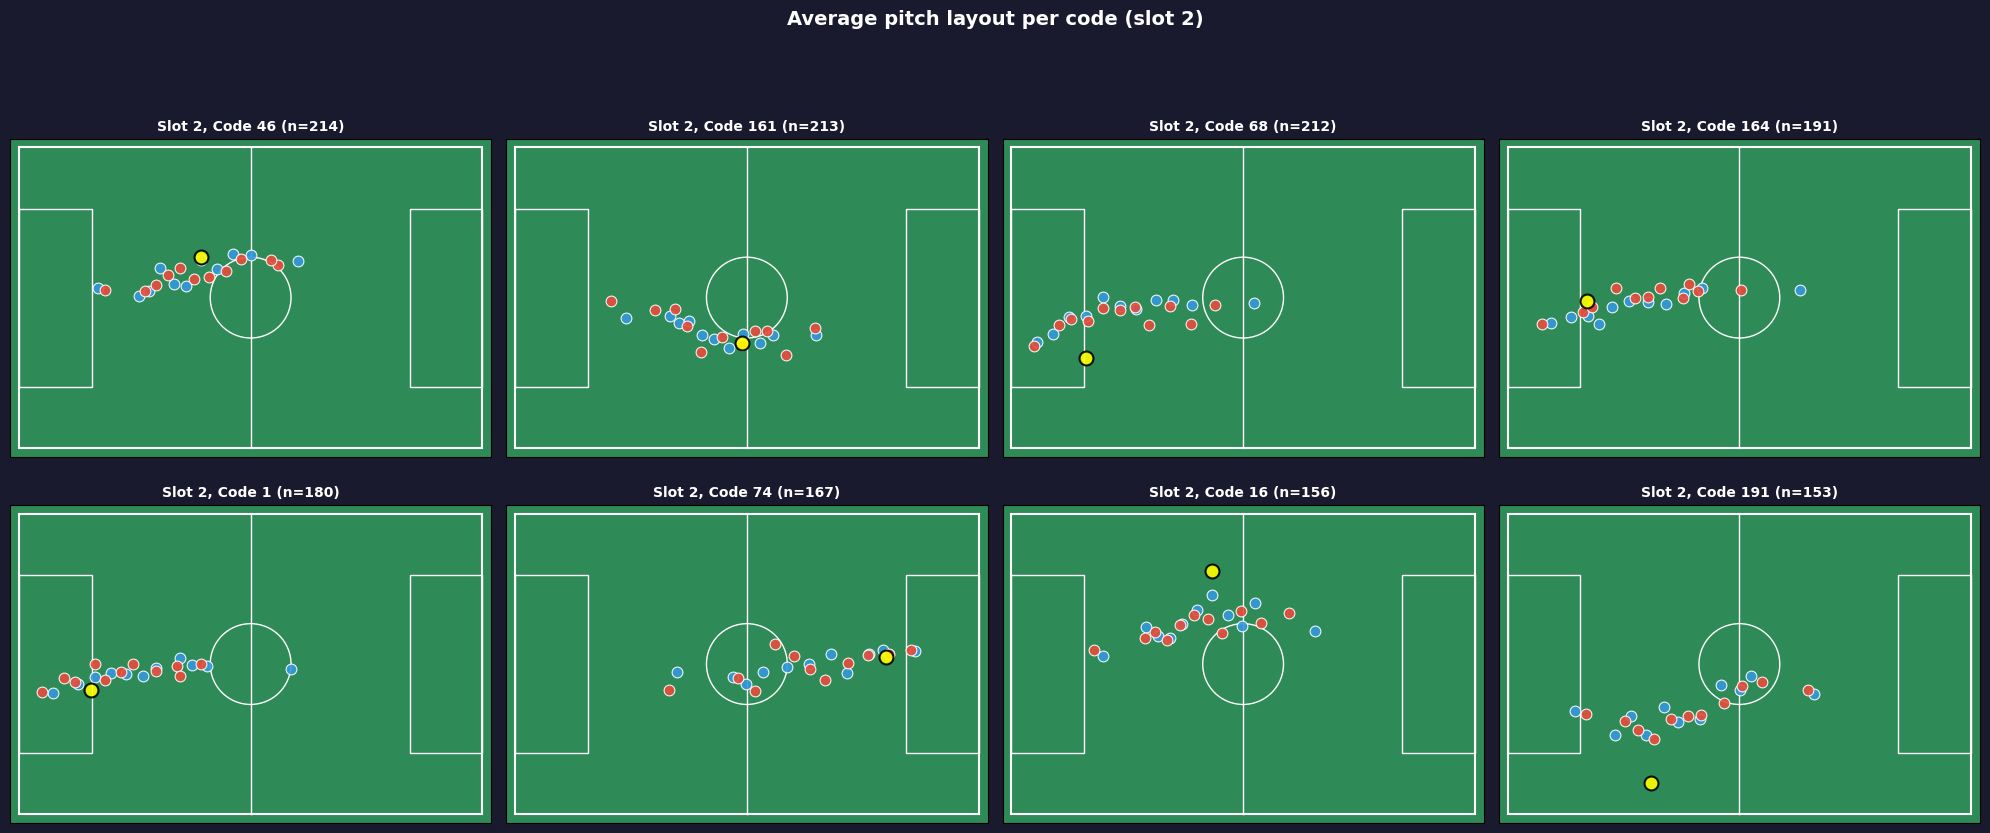

In [16]:
# For the top-N most used codes, show the average pitch layout
# We pick one specific slot to keep it interpretable

SLOT_TO_SHOW = 2  # change this to explore other slots
TOP_N_CODES = 8   # how many codes to visualize

slot_codes = all_tokens[:, SLOT_TO_SHOW].numpy()
code_counts = Counter(slot_codes)
top_codes = [c for c, _ in code_counts.most_common(TOP_N_CODES)]

n_cols = 4
n_rows = (TOP_N_CODES + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten()
fig.patch.set_facecolor("#1a1a2e")

for idx, code in enumerate(top_codes):
    ax = axes[idx]
    draw_pitch(ax)

    # Find all frames where this slot used this code
    frame_mask = slot_codes == code
    gt_subset = all_gt[frame_mask]  # (N_matches, N_max, 4)

    # Average positions
    avg_feats = gt_subset.mean(dim=0)  # (N_max, 4)
    n_nodes = avg_feats.shape[0]

    for p in range(n_nodes):
        x_n, y_n, team, is_ball = avg_feats[p].tolist()
        x, y = denormalize(x_n, y_n)

        if is_ball > 0.5:
            # Ball node
            ax.scatter(x, y, c="yellow", s=100, edgecolors="black",
                       linewidths=1.5, zorder=6, marker="o", alpha=0.9)
        else:
            color = "#e74c3c" if team > 0.5 else "#3498db"
            ax.scatter(x, y, c=color, s=60, edgecolors="white",
                       linewidths=0.8, zorder=5, alpha=0.9)

    count = code_counts[code]
    ax.set_title(f"Slot {SLOT_TO_SHOW}, Code {code} (n={count})",
                 fontsize=10, color="white", fontweight="bold")

# Hide unused subplots
for idx in range(TOP_N_CODES, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f"Average pitch layout per code (slot {SLOT_TO_SHOW})",
             fontsize=14, color="white", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Individual frames for a code (not just average)

The average can hide variance. Let's also show a few individual frames for a specific code to see how consistent the pattern is.

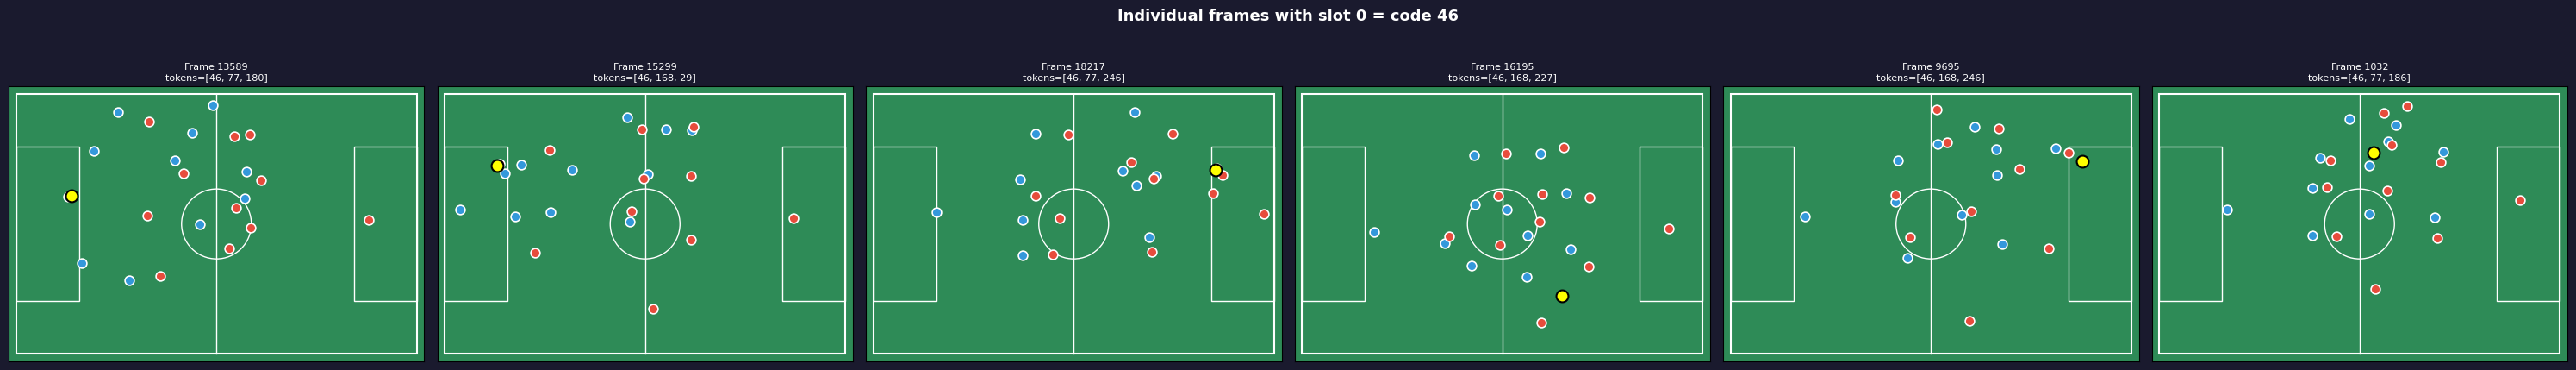

In [17]:
# Show N_EXAMPLES individual frames for a specific (slot, code) pair
SLOT_INSPECT = 0
CODE_INSPECT = top_codes[0]  # most common code for SLOT_TO_SHOW
N_EXAMPLES = 6

frame_mask = all_tokens[:, SLOT_INSPECT].numpy() == CODE_INSPECT
matching_indices = np.where(frame_mask)[0]
rng = np.random.default_rng(42)
sample_idx = rng.choice(matching_indices, size=min(N_EXAMPLES, len(matching_indices)), replace=False)

fig, axes = plt.subplots(1, len(sample_idx), figsize=(5 * len(sample_idx), 4.5))
if len(sample_idx) == 1:
    axes = [axes]
fig.patch.set_facecolor("#1a1a2e")

for col, fi in enumerate(sample_idx):
    ax = axes[col]
    draw_pitch(ax)
    feats = all_gt[fi]  # (N_max, 4)
    n_nodes = feats.shape[0]
    for p in range(n_nodes):
        x_n, y_n, team, is_ball = feats[p].tolist()
        x, y = denormalize(x_n, y_n)
        if is_ball > 0.5:
            ax.scatter(x, y, c="yellow", s=100, edgecolors="black",
                       linewidths=1.5, zorder=6, marker="o")
        else:
            color = "#e74c3c" if team > 0.5 else "#3498db"
            edge = "white"
            ax.scatter(x, y, c=color, s=60, edgecolors=edge, linewidths=1.2, zorder=5)
    frame_codes = all_tokens[fi].tolist()
    ax.set_title(f"Frame {fi}\ntokens={frame_codes}", fontsize=8, color="white")

fig.suptitle(f"Individual frames with slot {SLOT_INSPECT} = code {CODE_INSPECT}",
             fontsize=13, color="white", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 7. Codebook embedding space (t-SNE)

With product quantization, each slot has its own codebook. We project all codebook vectors to 2D, coloring by slot. If slots learned different concepts, their embeddings should form distinct clusters.

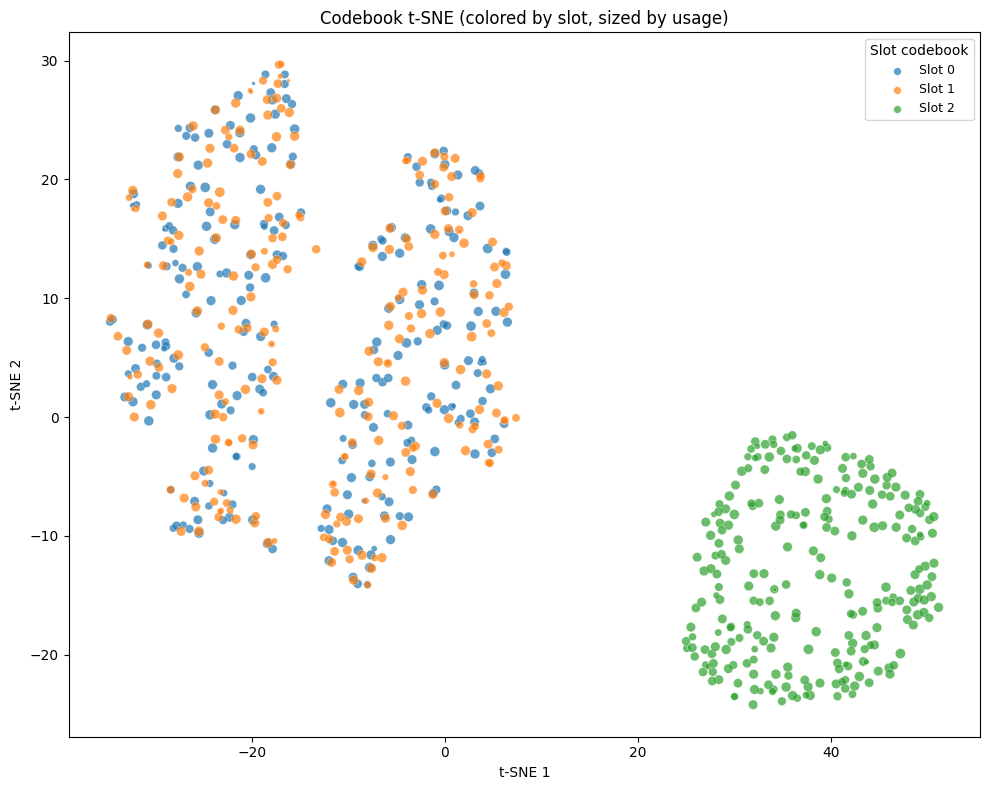

In [18]:
from sklearn.manifold import TSNE

# Gather codebook weights from all slots
if is_product:
    all_weights = []
    all_slot_labels = []
    all_usage = []
    for s in range(T):
        w = model.quantizer.codebooks[s].weight.detach().cpu().numpy()  # (K, D)
        all_weights.append(w)
        all_slot_labels.extend([s] * K)
        all_usage.extend(usage_matrix[s].tolist())
    all_weights = np.concatenate(all_weights, axis=0)  # (T*K, D)
    all_slot_labels = np.array(all_slot_labels)
    all_usage = np.array(all_usage)
else:
    all_weights = model.quantizer.codebook.weight.detach().cpu().numpy()
    all_slot_labels = np.argmax(usage_matrix, axis=0)
    all_slot_labels = np.tile(all_slot_labels, 1)
    all_usage = usage_matrix.sum(axis=0)

is_alive = all_usage > 0
alive_idx = np.where(is_alive)[0]

tsne = TSNE(n_components=2, perplexity=min(30, len(alive_idx) - 1), random_state=42)
coords = tsne.fit_transform(all_weights[alive_idx])

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.tab10
for slot in range(T):
    mask = all_slot_labels[alive_idx] == slot
    if mask.any():
        sizes = np.log1p(all_usage[alive_idx][mask]) * 10
        ax.scatter(coords[mask, 0], coords[mask, 1], c=[cmap(slot)],
                   s=sizes, label=f"Slot {slot}", alpha=0.7, edgecolors="white", linewidths=0.3)

ax.legend(title="Slot codebook", fontsize=9)
ax.set_title("Codebook t-SNE (colored by slot, sized by usage)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 8. Summary statistics

In [19]:
print("=" * 60)
print("VQ-VAE INTERPRETABILITY SUMMARY")
print("=" * 60)

n_frames = all_tokens.shape[0]

# Per-slot alive codes
alive_per_slot = [(usage_matrix[s] > 0).sum() for s in range(T)]
total_alive = sum(alive_per_slot)
total_possible = T * K

# Unique T-token sequences
unique_sequences = len(set(tuple(row) for row in all_tokens.numpy()))

# Per-frame token diversity (less meaningful for product quantization since codes are in different spaces)
per_frame_unique = np.array([len(set(row)) for row in all_tokens.numpy()])

print(f"\nQuantizer type: {'Product (independent codebooks)' if is_product else 'Shared'}")
print(f"Dataset: {n_frames} frames, {SPLIT} split")
print(f"Tokens per frame: T={T}, codebook size per slot: K={K}")
print(f"\nPer-slot codebook utilization:")
for s in range(T):
    print(f"  Slot {s}: {alive_per_slot[s]}/{K} codes alive ({alive_per_slot[s]/K*100:.1f}%)")
print(f"Total alive: {total_alive}/{total_possible}")

print(f"\nUnique {T}-token sequences: {unique_sequences} / {n_frames} frames ({unique_sequences/n_frames*100:.1f}%)")
print(f"Per-frame distinct tokens: mean={per_frame_unique.mean():.1f}, min={per_frame_unique.min()}, max={per_frame_unique.max()} (out of {T})")

print(f"\nPer-slot entropy (bits):")
for slot, ent in enumerate(slot_entropies):
    print(f"  Slot {slot}: {ent:.2f} / {np.log2(K):.2f}  (effective codes: {2**ent:.0f})")
print(f"\nMean slot entropy: {np.mean(slot_entropies):.2f} bits")
print(f"Total information capacity: {T} slots x {np.mean(slot_entropies):.1f} bits/slot = {T * np.mean(slot_entropies):.1f} bits/frame")
print(f"GPT vocab size: {T} x {K} = {T * K} token types (with slot-offset IDs)")

VQ-VAE INTERPRETABILITY SUMMARY

Quantizer type: Product (independent codebooks)
Dataset: 20053 frames, val split
Tokens per frame: T=3, codebook size per slot: K=256

Per-slot codebook utilization:
  Slot 0: 254/256 codes alive (99.2%)
  Slot 1: 250/256 codes alive (97.7%)
  Slot 2: 253/256 codes alive (98.8%)
Total alive: 757/768

Unique 3-token sequences: 11659 / 20053 frames (58.1%)
Per-frame distinct tokens: mean=3.0, min=2, max=3 (out of 3)

Per-slot entropy (bits):
  Slot 0: 7.71 / 8.00  (effective codes: 210)
  Slot 1: 7.66 / 8.00  (effective codes: 202)
  Slot 2: 7.75 / 8.00  (effective codes: 216)

Mean slot entropy: 7.71 bits
Total information capacity: 3 slots x 7.7 bits/slot = 23.1 bits/frame
GPT vocab size: 3 x 256 = 768 token types (with slot-offset IDs)
